In [1]:
import hashlib
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT  = Path("C:/Users/Lenovo/Documents/TRADING-BOT")
DATA_FILE  = REPO_ROOT / "data" / "raw" / "BTCUSDT_M1.csv"
OUTPUT_DIR = REPO_ROOT / "research" / "experiments" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Frozen parameters (spec S2-r3 — NEVER change in this notebook) ────────────
FROZEN_PARAMS = {
    "ema_slow":             100,
    "ema_fast":             50,
    "stoch_k_period":       8,
    "stoch_d_smooth":       3,
    "stoch_signal_smooth":  3,
    "stoch_oversold":       20,
    "stoch_overbought":     80,
    "sl_pct":               0.00075,   # 0.075%
    "tp_pct":               0.0020,    # 0.20%
    "max_holding_candles":  30,
    "session_start_utc":    12,
    "session_end_utc":      16,
    "taker_fee_per_side":   0.0004,    # 0.04%
    "capital_usdt":         10_000,
    "risk_per_trade_pct":   0.005,
}

SPEC_HASH = None  # computed in Cell 2 once dataset is loaded

print("Cell 1 OK")
print(f"Output dir: {OUTPUT_DIR}")

Cell 1 OK
Output dir: C:\Users\Lenovo\Documents\TRADING-BOT\research\experiments\outputs


In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_FILE)
print(f"Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols")

# ── UTC enforcement — zero naive datetimes ─────────────────────────────────────
df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='ms', utc=True)

# ── SPEC_HASH: sha256(params + dataset fingerprint) ────────────────────────────
with open(DATA_FILE, 'rb') as _f:
    _dataset_sha256 = hashlib.sha256(_f.read()).hexdigest()

SPEC_HASH = hashlib.sha256(json.dumps({
    "spec_version":   "S2-r3",
    "dataset_file":   "BTCUSDT_M1.csv",
    "dataset_sha256": _dataset_sha256,
    "params":         FROZEN_PARAMS,
}, sort_keys=True).encode()).hexdigest()[:12]

print(f"Dataset SHA256 (16-char prefix): {_dataset_sha256[:16]}...")
print(f"SPEC_HASH: {SPEC_HASH}")

# ── Sort & cast ────────────────────────────────────────────────────────────────
df_raw = df_raw.sort_values('open_time').reset_index(drop=True)
for col in ['open', 'high', 'low', 'close', 'volume']:
    df_raw[col] = df_raw[col].astype(float)

# ── Session filter: 12:00–16:00 UTC (exclusive upper bound) ────────────────────
mask = (
    (df_raw['open_time'].dt.hour >= FROZEN_PARAMS['session_start_utc']) &
    (df_raw['open_time'].dt.hour <  FROZEN_PARAMS['session_end_utc'])
)
df = df_raw[mask].copy().reset_index(drop=True)

print(f"\nFull dataset:              {len(df_raw):,} candles")
print(f"Session filtered (12-16 UTC): {len(df):,} candles")
print(f"Range: {df['open_time'].iloc[0]}  →  {df['open_time'].iloc[-1]}")

Loaded: 518,401 rows x 12 cols
Dataset SHA256 (16-char prefix): bcec4ad427e5d1a0...
SPEC_HASH: c555ac9efd53

Full dataset:              518,401 candles
Session filtered (12-16 UTC): 86,400 candles
Range: 2025-05-30 12:00:00+00:00  →  2026-05-24 15:59:00+00:00


In [3]:
# ── EMA 50 / 100  (adjust=False = standard exponential weighting) ─────────────
p = FROZEN_PARAMS

df['ema50']  = df['close'].ewm(span=p['ema_fast'], adjust=False).mean()
df['ema100'] = df['close'].ewm(span=p['ema_slow'], adjust=False).mean()

_warm = p['ema_slow'] * 3
sample = df.iloc[_warm:_warm + 4][['open_time', 'close', 'ema50', 'ema100']]
print(sample.to_string(index=False))
print(f"\nMean |EMA50 - EMA100|: {(df['ema50'] - df['ema100']).abs().mean():.2f} USDT")
print("Cell 3 OK")

                open_time     close         ema50        ema100
2025-05-31 13:00:00+00:00 103991.39 104033.448652 104363.070712
2025-05-31 13:01:00+00:00 104026.08 104033.159685 104356.397629
2025-05-31 13:02:00+00:00 104057.51 104034.114600 104350.479062
2025-05-31 13:03:00+00:00 104127.28 104037.768145 104346.059278

Mean |EMA50 - EMA100|: 164.44 USDT
Cell 3 OK


In [4]:
# ── Stochastic (8, 3, 3) — Full Stochastic ────────────────────────────────────
#   Raw %K  = 100 * (close - lowest_low[k]) / (highest_high[k] - lowest_low[k])
#   Slow %K = SMA(raw_%K, d_smooth)         — stoch_k in entry logic
#   Signal  = SMA(slow_%K, sig_smooth)      — stoch_d in entry logic

k   = p['stoch_k_period']
d   = p['stoch_d_smooth']
sig = p['stoch_signal_smooth']

_ll    = df['low'].rolling(k).min()
_hh    = df['high'].rolling(k).max()
_range = (_hh - _ll).replace(0, np.nan)

_raw_k        = 100.0 * (df['close'] - _ll) / _range
df['stoch_k'] = _raw_k.rolling(d).mean()           # slow %K
df['stoch_d'] = df['stoch_k'].rolling(sig).mean()  # signal line

warmup = k + d + sig - 2
print(f"Warmup rows: {warmup}")
print(f"NaN stoch_k: {df['stoch_k'].isna().sum()}  |  NaN stoch_d: {df['stoch_d'].isna().sum()}")
print(df[['open_time', 'close', 'stoch_k', 'stoch_d']].dropna().tail(4).to_string(index=False))
print("Cell 4 OK")

Warmup rows: 12
NaN stoch_k: 9  |  NaN stoch_d: 11
                open_time    close   stoch_k   stoch_d
2026-05-24 15:56:00+00:00 76387.56 12.092088 13.885263
2026-05-24 15:57:00+00:00 76387.56 11.981508 12.767321
2026-05-24 15:58:00+00:00 76362.79 11.552547 11.875381
2026-05-24 15:59:00+00:00 76371.59 12.245599 11.926551
Cell 4 OK


Spread spikes > 0.1%: 0 candles (0.00%)
Spread P80 median:    0.0050%
Spread P80 mean:      0.0050%


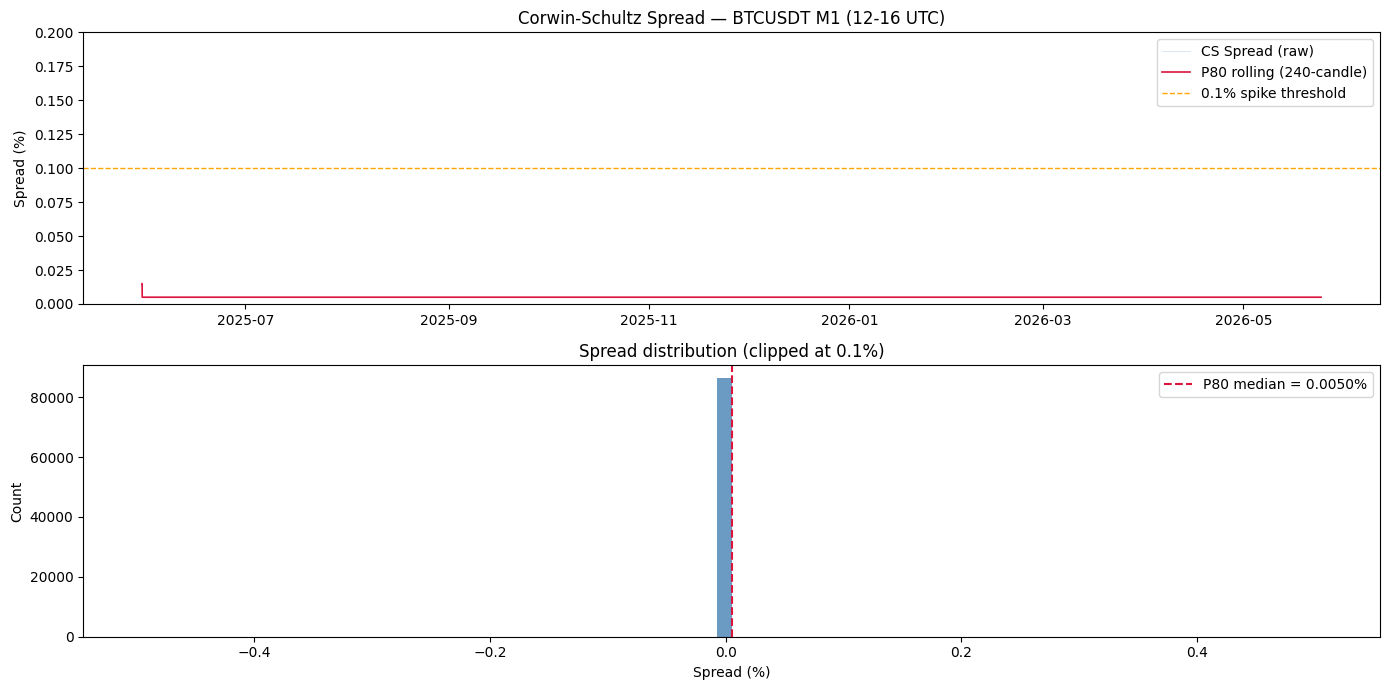

Saved: 01_spread_validation.png
VALIDATE: P80 should be ~0.010-0.020%. Spikes >0.1% are anomalous.


In [5]:
# ── Corwin-Schultz Spread Estimator ───────────────────────────────────────────
CS_WINDOW = 240  # 4h rolling P80

def corwin_schultz_spread(high: pd.Series, low: pd.Series) -> pd.Series:
    beta  = np.log(high / low) ** 2
    _hi2  = pd.concat([high, high.shift(1)], axis=1).max(axis=1)
    _lo2  = pd.concat([low,  low.shift(1)],  axis=1).min(axis=1)
    gamma = np.log(_hi2 / _lo2) ** 2
    k1    = 3.0 - 2.0 * np.sqrt(2.0)
    alpha = (np.sqrt(2.0 * beta) - np.sqrt(beta)) / k1 - np.sqrt(gamma / k1)
    alpha = alpha.clip(lower=0.0)
    spread = 2.0 * (np.exp(alpha) - 1.0) / (1.0 + np.exp(alpha))
    return spread.clip(lower=0.00005)  # floor at 0.005%

df['spread_cs']  = corwin_schultz_spread(df['high'], df['low'])
df['spread_p80'] = (
    df['spread_cs']
    .rolling(CS_WINDOW, min_periods=10)
    .quantile(0.80)
    .fillna(0.00015)  # fallback 0.015% for first rows
)

n_spikes = (df['spread_cs'] > 0.001).sum()
print(f"Spread spikes > 0.1%: {n_spikes} candles ({n_spikes/len(df)*100:.2f}%)")
print(f"Spread P80 median:    {df['spread_p80'].median()*100:.4f}%")
print(f"Spread P80 mean:      {df['spread_p80'].mean()*100:.4f}%")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
ax1.plot(df['open_time'], df['spread_cs'] * 100,
         alpha=0.35, lw=0.4, color='steelblue', label='CS Spread (raw)')
ax1.plot(df['open_time'], df['spread_p80'] * 100,
         color='crimson', lw=1.2, label='P80 rolling (240-candle)')
ax1.axhline(0.1, color='orange', ls='--', lw=1, label='0.1% spike threshold')
ax1.set_ylim(0, 0.2)
ax1.set_ylabel('Spread (%)')
ax1.set_title('Corwin-Schultz Spread — BTCUSDT M1 (12-16 UTC)')
ax1.legend()

ax2.hist(df['spread_cs'].clip(upper=0.001) * 100,
         bins=80, color='steelblue', edgecolor='none', alpha=0.8)
ax2.axvline(df['spread_p80'].median() * 100, color='crimson', ls='--',
            label=f"P80 median = {df['spread_p80'].median()*100:.4f}%")
ax2.set_xlabel('Spread (%)')
ax2.set_ylabel('Count')
ax2.set_title('Spread distribution (clipped at 0.1%)')
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_spread_validation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: 01_spread_validation.png")
print("VALIDATE: P80 should be ~0.010-0.020%. Spikes >0.1% are anomalous.")

In [6]:
# ── Regime Tagging (for post-analysis only — NOT used as signals) ──────────────
REGIME_WINDOW = 240

# Volatility regime: rolling ATR-pct percentiles
df['atr_pct'] = (df['high'] - df['low']) / df['close']
_atr_p33 = df['atr_pct'].rolling(REGIME_WINDOW, min_periods=1).quantile(0.33)
_atr_p66 = df['atr_pct'].rolling(REGIME_WINDOW, min_periods=1).quantile(0.66)
df['volatility_regime'] = 'Medium'
df.loc[df['atr_pct'] < _atr_p33, 'volatility_regime'] = 'Low'
df.loc[df['atr_pct'] > _atr_p66, 'volatility_regime'] = 'High'

# Trend regime: EMA-spread percentile
df['ema_spread_pct'] = (df['ema50'] - df['ema100']).abs() / df['close']
_esp_p80 = df['ema_spread_pct'].rolling(REGIME_WINDOW, min_periods=1).quantile(0.80)
df['trend_regime'] = 'Ranging'
df.loc[df['ema_spread_pct'] > _esp_p80, 'trend_regime'] = 'Trending'

print("Volatility regime:")
print(df['volatility_regime'].value_counts(normalize=True).mul(100).round(1))
print("\nTrend regime:")
print(df['trend_regime'].value_counts(normalize=True).mul(100).round(1))
print("Cell 6 OK")

Volatility regime:
volatility_regime
High      35.5
Low       32.9
Medium    31.6
Name: proportion, dtype: float64

Trend regime:
trend_regime
Ranging     79.6
Trending    20.4
Name: proportion, dtype: float64
Cell 6 OK


In [7]:
# ── Signal generation ──────────────────────────────────────────────────────────
# Spec: signal generated on candle T close; entry at candle T+1 open.
# Anti-leakage: .shift(1) moves the signal forward by 1 candle.

_sk_prev = df['stoch_k'].shift(1)
_sd_prev = df['stoch_d'].shift(1)

# LONG: price above both EMAs + stoch crosses up from oversold
_long = (
    (df['close'] > df['ema50'])                  &
    (df['close'] > df['ema100'])                 &
    (_sk_prev < p['stoch_oversold'])             &
    (_sk_prev <= _sd_prev)                       &
    (df['stoch_k'] > df['stoch_d'])
)

# SHORT: price below both EMAs + stoch crosses down from overbought
_short = (
    (df['close'] < df['ema50'])                  &
    (df['close'] < df['ema100'])                 &
    (_sk_prev > p['stoch_overbought'])           &
    (_sk_prev >= _sd_prev)                       &
    (df['stoch_k'] < df['stoch_d'])
)

# Shift by 1: signal[i]=True means enter at open[i] (signal was on candle i-1)
df['signal_long']  = _long.shift(1).fillna(False)
df['signal_short'] = _short.shift(1).fillna(False)

n_long  = int(df['signal_long'].sum())
n_short = int(df['signal_short'].sum())
print(f"LONG signals:  {n_long:,}")
print(f"SHORT signals: {n_short:,}")
print(f"Total:         {n_long + n_short:,}")
print(f"Signal rate:   {(n_long + n_short) / len(df) * 100:.2f}% of session candles")
print("Cell 7 OK — entry at T+1 open enforced via .shift(1)")

LONG signals:  1,369
SHORT signals: 1,326
Total:         2,695
Signal rate:   3.12% of session candles
Cell 7 OK — entry at T+1 open enforced via .shift(1)


In [8]:
# ── Train / Hold-out split ─────────────────────────────────────────────────────
# Train:   months 1-10  (2025-05-29 → 2026-03-29)
# Holdout: months 11-12 (2026-03-29 → 2026-05-24)

SPLIT_DATE = pd.Timestamp('2026-03-29', tz='UTC')

df['split'] = 'train'
df.loc[df['open_time'] >= SPLIT_DATE, 'split'] = 'holdout'

n_train   = (df['split'] == 'train').sum()
n_holdout = (df['split'] == 'holdout').sum()
print(f"Train candles:   {n_train:,}  ({n_train/(n_train+n_holdout)*100:.1f}%)")
print(f"Holdout candles: {n_holdout:,}  ({n_holdout/(n_train+n_holdout)*100:.1f}%)")
print(f"Train end:     {df[df['split']=='train']['open_time'].max()}")
print(f"Holdout start: {df[df['split']=='holdout']['open_time'].min()}")
print("Cell 8 OK")

Train candles:   72,720  (84.2%)
Holdout candles: 13,680  (15.8%)
Train end:     2026-03-28 15:59:00+00:00
Holdout start: 2026-03-29 12:00:00+00:00
Cell 8 OK


In [9]:
# ── Backtest ───────────────────────────────────────────────────────────────────
# Rules enforced:
#   - One position at a time, no pyramiding
#   - SL first in same candle (conservative)
#   - EOD exit at 15:59 UTC (no cross-session carry)
#   - No entry on last candle of session (15:59)

def run_backtest(df: pd.DataFrame, params: dict, spec_hash: str) -> pd.DataFrame:
    p = params
    records = []

    # Pre-extract arrays for loop performance
    opens    = df['open'].values
    highs    = df['high'].values
    lows     = df['low'].values
    closes   = df['close'].values
    times    = df['open_time'].values       # numpy datetime64[ns, UTC]
    sig_l    = df['signal_long'].values
    sig_s    = df['signal_short'].values
    sp_p80   = df['spread_p80'].values
    ema50_v  = df['ema50'].values
    ema100_v = df['ema100'].values
    sk_v     = df['stoch_k'].values
    sd_v     = df['stoch_d'].values
    vol_reg  = df['volatility_regime'].values
    tr_reg   = df['trend_regime'].values
    splits   = df['split'].values

    in_pos       = False
    trade_id     = 0
    direction    = None
    entry_price  = None
    sl_price     = None
    tp_price     = None
    entry_time   = None
    entry_date   = None
    candles_held = 0
    mae = mfe    = 0.0
    spread_at_entry     = 0.0
    ema50_at_entry      = 0.0
    ema100_at_entry     = 0.0
    stoch_k_at_entry    = 0.0
    stoch_d_at_entry    = 0.0
    vol_at_entry        = ''
    tr_at_entry         = ''
    split_at_entry      = ''
    entry_month         = ''

    for i in range(len(df)):
        t = pd.Timestamp(times[i])

        if in_pos:
            candles_held += 1
            h, l, c = highs[i], lows[i], closes[i]

            # Force exit if position crossed a session boundary (data gap safeguard)
            is_cross_day = (t.date() != entry_date)
            is_eod       = (t.hour == 15 and t.minute >= 59)

            if direction == 'LONG':
                adverse   = (l - entry_price) / entry_price
                favorable = (h - entry_price) / entry_price
            else:
                adverse   = (entry_price - h) / entry_price
                favorable = (entry_price - l) / entry_price
            mae = min(mae, adverse)
            mfe = max(mfe, favorable)

            exit_price  = None
            exit_reason = None

            if direction == 'LONG':
                if l <= sl_price:
                    exit_price, exit_reason = sl_price, 'SL'
                elif h >= tp_price:
                    exit_price, exit_reason = tp_price, 'TP'
                elif candles_held >= p['max_holding_candles']:
                    exit_price, exit_reason = c, 'MAX_HOLD'
                elif is_eod or is_cross_day:
                    exit_price, exit_reason = c, 'EOD'
            else:
                if h >= sl_price:
                    exit_price, exit_reason = sl_price, 'SL'
                elif l <= tp_price:
                    exit_price, exit_reason = tp_price, 'TP'
                elif candles_held >= p['max_holding_candles']:
                    exit_price, exit_reason = c, 'MAX_HOLD'
                elif is_eod or is_cross_day:
                    exit_price, exit_reason = c, 'EOD'

            if exit_price is not None:
                pnl_gross = ((exit_price - entry_price) / entry_price
                             if direction == 'LONG'
                             else (entry_price - exit_price) / entry_price)
                fees_pct   = p['taker_fee_per_side'] * 2.0
                cost_total = fees_pct + spread_at_entry
                pnl_net    = pnl_gross - cost_total

                records.append({
                    'trade_id':          trade_id,
                    'entry_time':        pd.Timestamp(entry_time),
                    'exit_time':         t,
                    'direction':         direction,
                    'entry_price':       float(entry_price),
                    'exit_price':        float(exit_price),
                    'exit_reason':       exit_reason,
                    'holding_candles':   candles_held,
                    'spread_pct':        float(spread_at_entry),
                    'fees_pct':          float(fees_pct),
                    'cost_total_pct':    float(cost_total),
                    'pnl_gross_pct':     float(pnl_gross),
                    'pnl_net_pct':       float(pnl_net),
                    'mae_pct':           float(abs(mae)),
                    'mfe_pct':           float(mfe),
                    'ema50_at_entry':    float(ema50_at_entry),
                    'ema100_at_entry':   float(ema100_at_entry),
                    'stoch_k_at_entry':  float(stoch_k_at_entry),
                    'stoch_d_at_entry':  float(stoch_d_at_entry),
                    'volatility_regime': vol_at_entry,
                    'trend_regime':      tr_at_entry,
                    'split':             split_at_entry,
                    'month':             entry_month,
                    'spec_hash':         spec_hash,
                })
                in_pos   = False
                trade_id += 1

        else:
            # Skip NaN warmup rows
            if np.isnan(sk_v[i]) or np.isnan(sd_v[i]) or np.isnan(ema100_v[i]):
                continue

            direction_new = None
            if sig_l[i]:
                direction_new = 'LONG'
            elif sig_s[i]:
                direction_new = 'SHORT'

            if direction_new is not None:
                # Don't enter on last session candle (would miss EOD exit)
                if t.hour == 15 and t.minute >= 59:
                    continue

                in_pos              = True
                direction           = direction_new
                entry_price         = opens[i]
                entry_time          = times[i]
                entry_date          = t.date()
                candles_held        = 0
                mae = mfe           = 0.0
                spread_at_entry     = float(sp_p80[i]) if not np.isnan(sp_p80[i]) else 0.00015
                ema50_at_entry      = float(ema50_v[i])
                ema100_at_entry     = float(ema100_v[i])
                stoch_k_at_entry    = float(sk_v[i])
                stoch_d_at_entry    = float(sd_v[i])
                vol_at_entry        = vol_reg[i]
                tr_at_entry         = tr_reg[i]
                split_at_entry      = splits[i]
                entry_month         = t.strftime('%Y-%m')

                if direction == 'LONG':
                    sl_price = entry_price * (1.0 - p['sl_pct'])
                    tp_price = entry_price * (1.0 + p['tp_pct'])
                else:
                    sl_price = entry_price * (1.0 + p['sl_pct'])
                    tp_price = entry_price * (1.0 - p['tp_pct'])

    return pd.DataFrame(records)


print("Running backtest...")
trades = run_backtest(df, FROZEN_PARAMS, SPEC_HASH)
print(f"Total trades: {len(trades):,}")
print(f"  Train:   {(trades['split']=='train').sum():,}")
print(f"  Holdout: {(trades['split']=='holdout').sum():,}")
print(f"\nExit distribution:")
print(trades['exit_reason'].value_counts().to_string())
print(f"\nDirection split:")
print(trades['direction'].value_counts().to_string())

Running backtest...
Total trades: 2,169
  Train:   1,827
  Holdout: 342

Exit distribution:
exit_reason
SL          1355
TP           568
MAX_HOLD     186
EOD           60

Direction split:
direction
SHORT    1112
LONG     1057


In [10]:
# ── Equity Curve ───────────────────────────────────────────────────────────────
def compute_equity_curve(t: pd.DataFrame, capital: float) -> pd.DataFrame:
    t = t.sort_values('exit_time').copy().reset_index(drop=True)
    t['cumulative_pnl_pct']   = t['pnl_net_pct'].cumsum()
    t['equity_usdt']          = capital * (1.0 + t['cumulative_pnl_pct'])
    t['peak_equity']          = t['equity_usdt'].cummax()
    t['rolling_drawdown_pct'] = (t['equity_usdt'] - t['peak_equity']) / t['peak_equity'] * 100.0

    count, streak = [], 0
    for v in (t['equity_usdt'] < t['peak_equity']).values:
        streak = streak + 1 if v else 0
        count.append(streak)
    t['underwater_trades'] = count
    return t


equity_all   = compute_equity_curve(trades,                                  FROZEN_PARAMS['capital_usdt'])
equity_train = compute_equity_curve(trades[trades['split']=='train'],        FROZEN_PARAMS['capital_usdt'])
equity_hold  = compute_equity_curve(trades[trades['split']=='holdout'],      FROZEN_PARAMS['capital_usdt'])

for label, eq in [('train', equity_train), ('holdout', equity_hold)]:
    if len(eq) == 0:
        print(f"{label}: no trades")
        continue
    print(f"{label:8s}  total_return={eq['cumulative_pnl_pct'].iloc[-1]*100:+.2f}%"
          f"  max_dd={eq['rolling_drawdown_pct'].min():.2f}%"
          f"  peak={eq['peak_equity'].max():.0f} USDT")

equity_all.to_csv(OUTPUT_DIR / '01_equity.csv', index=False)
print("\nSaved: outputs/01_equity.csv")

train     total_return=-135.75%  max_dd=-135.80%  peak=9984 USDT
holdout   total_return=-27.15%  max_dd=-27.07%  peak=9990 USDT

Saved: outputs/01_equity.csv


In [11]:
# ── Aggregate Metrics + Per-month Table ────────────────────────────────────────
def compute_expectancy(pnl: pd.Series) -> float:
    if len(pnl) == 0:
        return 0.0
    wins   = pnl[pnl > 0]
    losses = pnl[pnl <= 0]
    wr     = len(wins) / len(pnl)
    return wr * (wins.mean() if len(wins) else 0.0) - (1 - wr) * (losses.abs().mean() if len(losses) else 0.0)


def summary_metrics(t: pd.DataFrame, label: str) -> dict:
    if len(t) == 0:
        return {'split': label, 'n_trades': 0}
    pnl  = t['pnl_net_pct']
    wins = pnl[pnl > 0]
    loss = pnl[pnl <= 0]
    wr   = len(wins) / len(pnl)
    eq   = compute_equity_curve(t, FROZEN_PARAMS['capital_usdt'])
    return {
        'split':               label,
        'n_trades':            len(t),
        'win_rate':            round(wr, 4),
        'breakeven_wr':        0.618,
        'avg_win_net_pct':     round(wins.mean() * 100,        4) if len(wins) else 0.0,
        'avg_loss_net_pct':    round(loss.abs().mean() * 100,  4) if len(loss) else 0.0,
        'expectancy_net_pct':  round(compute_expectancy(pnl) * 100, 4),
        'total_return_pct':    round(pnl.sum() * 100, 2),
        'max_drawdown_pct':    round(eq['rolling_drawdown_pct'].min(), 2),
        'sharpe_ref':          round(pnl.mean() / pnl.std() if pnl.std() > 0 else 0.0, 3),
        'avg_mae_pct':         round(t['mae_pct'].mean() * 100, 4),
        'avg_mfe_pct':         round(t['mfe_pct'].mean() * 100, 4),
        'avg_holding_candles': round(t['holding_candles'].mean(), 1),
        'pct_tp':              round((t['exit_reason']=='TP').mean() * 100,       1),
        'pct_sl':              round((t['exit_reason']=='SL').mean() * 100,       1),
        'pct_max_hold':        round((t['exit_reason']=='MAX_HOLD').mean() * 100, 1),
        'pct_eod':             round((t['exit_reason']=='EOD').mean() * 100,      1),
    }


train_metrics   = summary_metrics(trades[trades['split']=='train'],   'train')
holdout_metrics = summary_metrics(trades[trades['split']=='holdout'], 'holdout')

mdf = pd.DataFrame([train_metrics, holdout_metrics]).set_index('split').T
print(mdf.to_string())

# ── Per-month breakdown ───────────────────────────────────────────────────────
monthly_rows = []
for (split, month), g in trades.groupby(['split', 'month']):
    pnl = g['pnl_net_pct']
    monthly_rows.append({
        'split': split, 'month': month,
        'n_trades':         len(g),
        'win_rate':         round((pnl > 0).mean(), 3),
        'expectancy_pct':   round(compute_expectancy(pnl) * 100, 4),
        'total_return_pct': round(pnl.sum() * 100, 2),
    })
monthly = pd.DataFrame(monthly_rows).sort_values(['split', 'month'])
print("\n── Per-month breakdown ──────────────────────────────────────────────")
print(monthly.to_string(index=False))

split                    train   holdout
n_trades             1827.0000  342.0000
win_rate                0.2906    0.2690
breakeven_wr            0.6180    0.6180
avg_win_net_pct         0.1083    0.1086
avg_loss_net_pct        0.1491    0.1486
expectancy_net_pct     -0.0743   -0.0794
total_return_pct     -135.7500  -27.1500
max_drawdown_pct     -135.8000  -27.0700
sharpe_ref             -0.6160   -0.6700
avg_mae_pct             0.0899    0.0902
avg_mfe_pct             0.1115    0.1056
avg_holding_candles     8.3000    8.4000
pct_tp                 26.5000   24.6000
pct_sl                 62.1000   64.6000
pct_max_hold            8.6000    8.5000
pct_eod                 2.8000    2.3000

── Per-month breakdown ──────────────────────────────────────────────
  split   month  n_trades  win_rate  expectancy_pct  total_return_pct
holdout 2026-03        19     0.316         -0.0685             -1.30
holdout 2026-04       189     0.291         -0.0767            -14.49
holdout 2026-05       

In [12]:
# ── Block Bootstrap CI on E_net (block_size=20, n_iter=1000) ───────────────────
BOOTSTRAP_N    = 1000
BOOTSTRAP_BLOCK = 20

def block_bootstrap_expectancy(pnl: pd.Series,
                                n_iter: int   = BOOTSTRAP_N,
                                block_size: int = BOOTSTRAP_BLOCK,
                                seed: int = 42) -> tuple:
    rng = np.random.default_rng(seed)
    arr = pnl.values
    n   = len(arr)
    results = []
    for _ in range(n_iter):
        idx = []
        while len(idx) < n:
            start = int(rng.integers(0, max(1, n - block_size)))
            idx.extend(range(start, min(start + block_size, n)))
        sample = arr[idx[:n]]
        results.append(compute_expectancy(pd.Series(sample)))
    lo, hi = np.percentile(results, [2.5, 97.5])
    return lo, hi, np.array(results)


train_pnl   = trades[trades['split']=='train']['pnl_net_pct']
holdout_pnl = trades[trades['split']=='holdout']['pnl_net_pct']

ci_lo_train, ci_hi_train, _boot_train = block_bootstrap_expectancy(train_pnl)
ci_lo_hold,  ci_hi_hold,  _boot_hold  = block_bootstrap_expectancy(holdout_pnl)

e_train = compute_expectancy(train_pnl)
e_hold  = compute_expectancy(holdout_pnl)

print(f"Train   E_net: {e_train*100:+.4f}%   95% CI: [{ci_lo_train*100:.4f}%, {ci_hi_train*100:.4f}%]")
print(f"Holdout E_net: {e_hold*100:+.4f}%   95% CI: [{ci_lo_hold*100:.4f}%,  {ci_hi_hold*100:.4f}%]")

holdout_metrics['expectancy_ci_95_lo_pct'] = round(ci_lo_hold * 100, 4)
holdout_metrics['expectancy_ci_95_hi_pct'] = round(ci_hi_hold * 100, 4)
print("Cell 12 OK")

Train   E_net: -0.0743%   95% CI: [-0.0799%, -0.0680%]
Holdout E_net: -0.0794%   95% CI: [-0.0913%,  -0.0637%]
Cell 12 OK


In [13]:
# ── Direction-Aware Baseline Monte Carlo (1000 sims) ──────────────────────────
# Problem with naive baseline: uniform 50/50 direction ignores trend regime.
# Fix: sample directions matching actual long/short ratio of strategy on train.

def direction_aware_baseline(df_full: pd.DataFrame,
                              train_trades: pd.DataFrame,
                              params: dict,
                              n_sims: int = 1000,
                              seed: int   = 42) -> np.ndarray:
    rng        = np.random.default_rng(seed)
    p          = params
    n          = len(train_trades)
    long_ratio = (train_trades['direction'] == 'LONG').mean()
    sess       = df_full[df_full['split'] == 'train'].reset_index(drop=True)
    max_idx    = len(sess) - p['max_holding_candles'] - 2

    if max_idx <= 0 or n == 0:
        return np.zeros(n_sims)

    e_sims = []
    for _ in range(n_sims):
        entries    = rng.integers(0, max_idx, size=n)
        directions = rng.choice(['LONG', 'SHORT'], size=n,
                                 p=[long_ratio, 1.0 - long_ratio])
        pnl_sim = []
        for idx, dirn in zip(entries, directions):
            ep = sess['open'].iloc[idx]
            sp = float(sess['spread_p80'].iloc[idx])
            if np.isnan(sp):
                sp = 0.00015
            fees = p['taker_fee_per_side'] * 2.0
            cost = fees + sp

            if dirn == 'LONG':
                sl_p = ep * (1.0 - p['sl_pct'])
                tp_p = ep * (1.0 + p['tp_pct'])
            else:
                sl_p = ep * (1.0 + p['sl_pct'])
                tp_p = ep * (1.0 - p['tp_pct'])

            exit_pnl = None
            for k in range(1, p['max_holding_candles'] + 1):
                if idx + k >= len(sess):
                    break
                h  = sess['high'].iloc[idx + k]
                l  = sess['low'].iloc[idx + k]
                c  = sess['close'].iloc[idx + k]
                tk = sess['open_time'].iloc[idx + k]
                eod = (tk.hour == 15 and tk.minute >= 59)

                if dirn == 'LONG':
                    if l <= sl_p:
                        exit_pnl = (sl_p - ep) / ep - cost; break
                    elif h >= tp_p:
                        exit_pnl = (tp_p - ep) / ep - cost; break
                    elif k == p['max_holding_candles'] or eod:
                        exit_pnl = (c - ep) / ep - cost; break
                else:
                    if h >= sl_p:
                        exit_pnl = (ep - sl_p) / ep - cost; break
                    elif l <= tp_p:
                        exit_pnl = (ep - tp_p) / ep - cost; break
                    elif k == p['max_holding_candles'] or eod:
                        exit_pnl = (ep - c) / ep - cost; break

            pnl_sim.append(exit_pnl if exit_pnl is not None else -cost)
        e_sims.append(compute_expectancy(pd.Series(pnl_sim)))

    return np.array(e_sims)


print("Running direction-aware baseline (1000 sims)... ~60-120s")
baseline_dist = direction_aware_baseline(df, trades[trades['split']=='train'],
                                          FROZEN_PARAMS, n_sims=1000)

baseline_p95    = float(np.percentile(baseline_dist, 95))
strategy_e_net  = compute_expectancy(holdout_pnl)

print(f"Baseline P95:          {baseline_p95*100:+.4f}%")
print(f"Strategy E_net (hold): {strategy_e_net*100:+.4f}%")
print(f"Strategy > P95:        {strategy_e_net > baseline_p95}")

np.savetxt(OUTPUT_DIR / '01_baseline_dist.csv', baseline_dist * 100,
           delimiter=',', header='baseline_e_net_pct', comments='')
print("Saved: outputs/01_baseline_dist.csv")

Running direction-aware baseline (1000 sims)... ~60-120s
Baseline P95:          -0.0731%
Strategy E_net (hold): -0.0794%
Strategy > P95:        False
Saved: outputs/01_baseline_dist.csv


In [14]:
# ── Regime Breakdown: E_net by volatility_regime x trend_regime ───────────────
regime_rows = []
for (split, vol, trend), g in trades.groupby(['split', 'volatility_regime', 'trend_regime']):
    pnl = g['pnl_net_pct']
    regime_rows.append({
        'split':             split,
        'volatility_regime': vol,
        'trend_regime':      trend,
        'n_trades':          len(g),
        'win_rate':          round((pnl > 0).mean(), 3),
        'expectancy_pct':    round(compute_expectancy(pnl) * 100, 4),
        'total_return_pct':  round(pnl.sum() * 100, 2),
    })

regime_df = pd.DataFrame(regime_rows)
print("E_net by regime:")
print(regime_df.to_string(index=False))

E_net by regime:
  split volatility_regime trend_regime  n_trades  win_rate  expectancy_pct  total_return_pct
holdout              High      Ranging        69     0.261         -0.0883             -6.09
holdout              High     Trending        33     0.394         -0.0459             -1.51
holdout               Low      Ranging        88     0.239         -0.0892             -7.85
holdout               Low     Trending        25     0.240         -0.0970             -2.43
holdout            Medium      Ranging        95     0.284         -0.0726             -6.90
holdout            Medium     Trending        32     0.219         -0.0742             -2.37
  train              High      Ranging       407     0.329         -0.0670            -27.27
  train              High     Trending       197     0.355         -0.0615            -12.12
  train               Low      Ranging       474     0.257         -0.0798            -37.81
  train               Low     Trending       162     

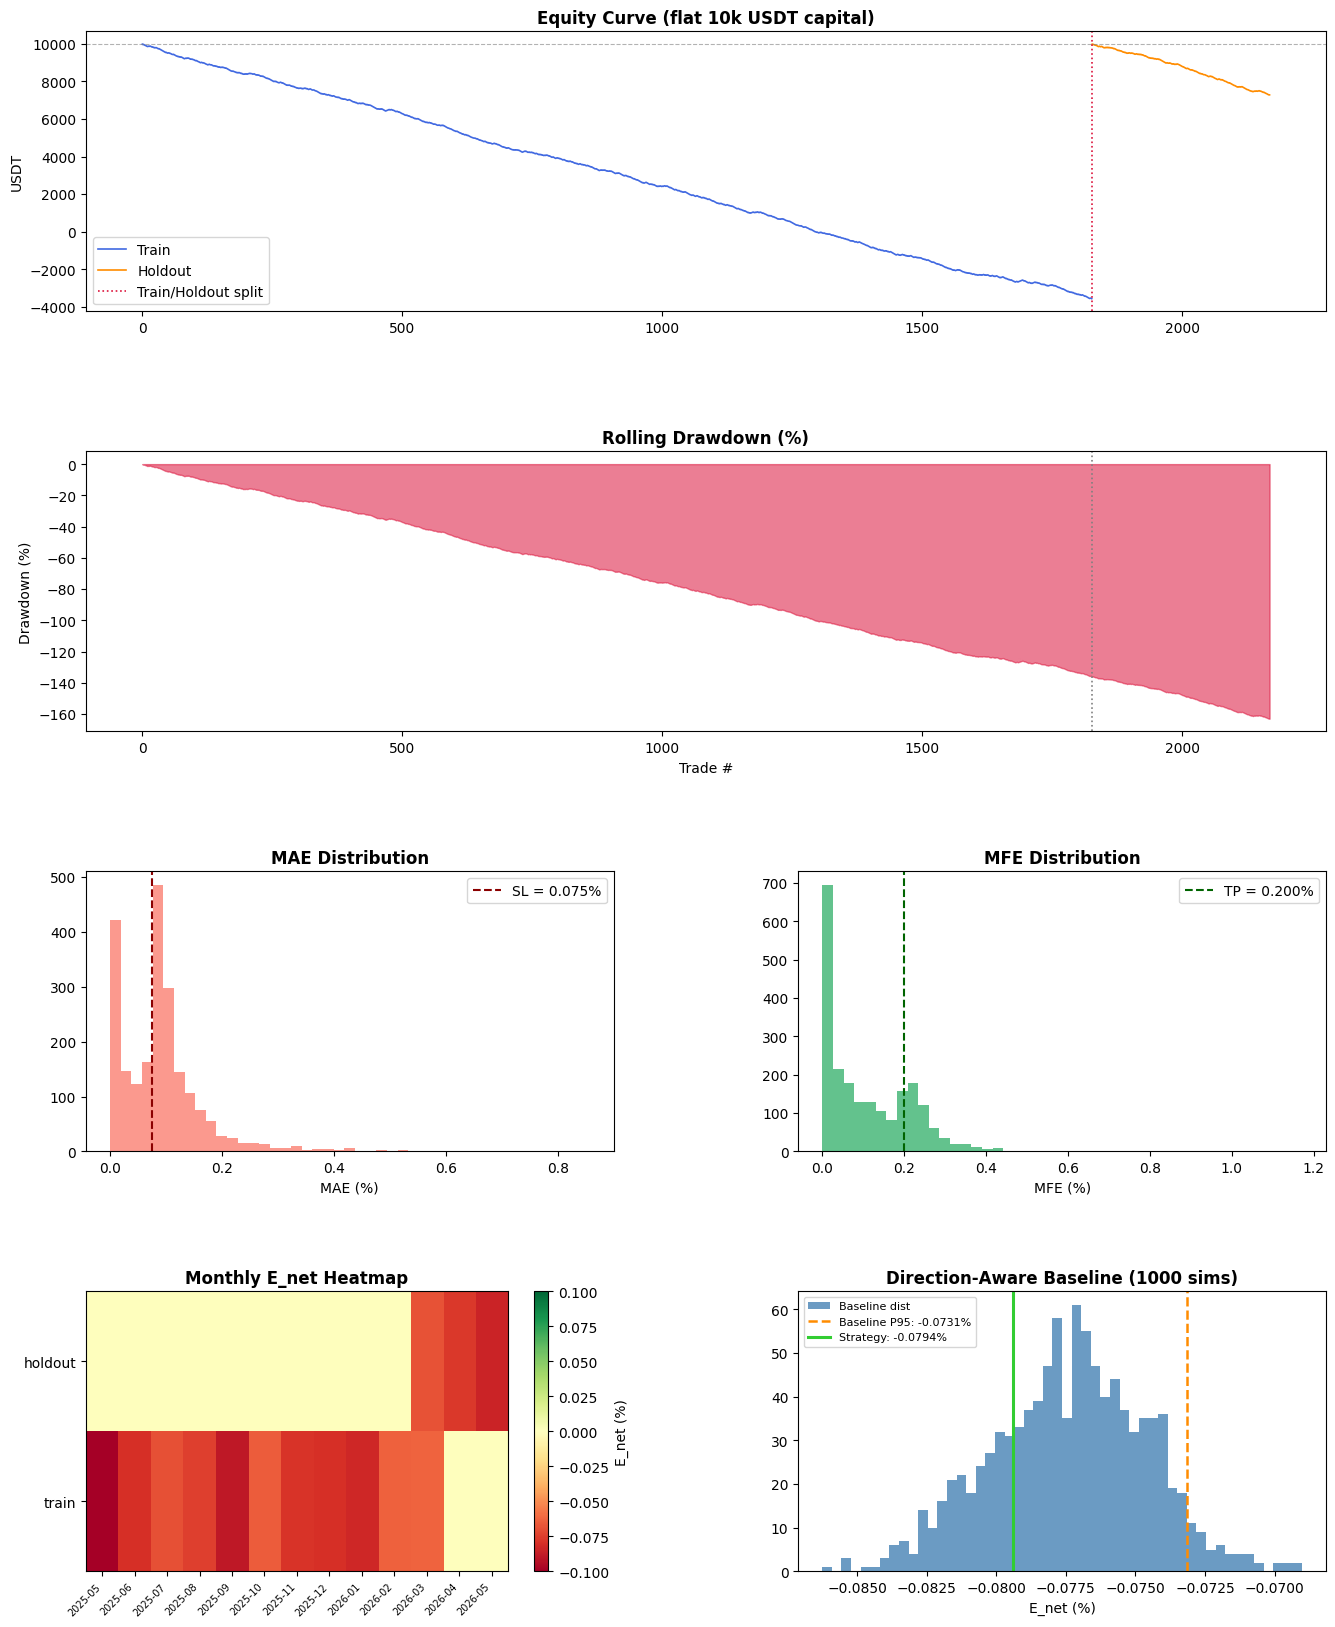

Saved: outputs/01_visualizations.png


In [15]:
# ── Visualizations ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 20))
gs  = GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.35)

# 1. Equity curve: train + holdout
ax1 = fig.add_subplot(gs[0, :])
if len(equity_train):
    ax1.plot(range(len(equity_train)), equity_train['equity_usdt'],
             color='royalblue', lw=1.2, label='Train')
if len(equity_hold):
    ax1.plot(range(len(equity_train), len(equity_train) + len(equity_hold)),
             equity_hold['equity_usdt'], color='darkorange', lw=1.2, label='Holdout')
ax1.axhline(FROZEN_PARAMS['capital_usdt'], color='gray', ls='--', lw=0.8, alpha=0.6)
ax1.axvline(len(equity_train), color='crimson', ls=':', lw=1.2, label='Train/Holdout split')
ax1.set_title('Equity Curve (flat 10k USDT capital)', fontweight='bold')
ax1.set_ylabel('USDT')
ax1.legend()

# 2. Drawdown
ax2 = fig.add_subplot(gs[1, :])
ax2.fill_between(range(len(equity_all)), equity_all['rolling_drawdown_pct'], 0,
                 alpha=0.55, color='crimson')
ax2.axvline(len(equity_train), color='gray', ls=':', lw=1.2)
ax2.set_title('Rolling Drawdown (%)', fontweight='bold')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Trade #')

# 3. MAE distribution vs SL
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(trades['mae_pct'] * 100, bins=45, color='salmon', edgecolor='none', alpha=0.8)
ax3.axvline(FROZEN_PARAMS['sl_pct'] * 100, color='darkred', ls='--', lw=1.5,
            label=f"SL = {FROZEN_PARAMS['sl_pct']*100:.3f}%")
ax3.set_title('MAE Distribution', fontweight='bold')
ax3.set_xlabel('MAE (%)')
ax3.legend()

# 4. MFE distribution vs TP
ax4 = fig.add_subplot(gs[2, 1])
ax4.hist(trades['mfe_pct'] * 100, bins=45, color='mediumseagreen', edgecolor='none', alpha=0.8)
ax4.axvline(FROZEN_PARAMS['tp_pct'] * 100, color='darkgreen', ls='--', lw=1.5,
            label=f"TP = {FROZEN_PARAMS['tp_pct']*100:.3f}%")
ax4.set_title('MFE Distribution', fontweight='bold')
ax4.set_xlabel('MFE (%)')
ax4.legend()

# 5. Monthly E_net heatmap
ax5 = fig.add_subplot(gs[3, 0])
if len(monthly) > 0:
    try:
        mp = monthly.pivot(index='split', columns='month', values='expectancy_pct').fillna(0)
        im = ax5.imshow(mp.values, aspect='auto', cmap='RdYlGn', vmin=-0.1, vmax=0.1)
        ax5.set_xticks(range(len(mp.columns)))
        ax5.set_xticklabels(mp.columns, rotation=45, ha='right', fontsize=7)
        ax5.set_yticks(range(len(mp.index)))
        ax5.set_yticklabels(mp.index)
        plt.colorbar(im, ax=ax5, label='E_net (%)')
    except Exception as e:
        ax5.text(0.5, 0.5, f'Heatmap unavailable:\n{e}', ha='center', va='center',
                 transform=ax5.transAxes)
ax5.set_title('Monthly E_net Heatmap', fontweight='bold')

# 6. Baseline vs strategy E_net
ax6 = fig.add_subplot(gs[3, 1])
ax6.hist(baseline_dist * 100, bins=50, color='steelblue', edgecolor='none', alpha=0.8,
         label='Baseline dist')
ax6.axvline(baseline_p95 * 100, color='darkorange', ls='--', lw=1.8,
            label=f'Baseline P95: {baseline_p95*100:.4f}%')
ax6.axvline(strategy_e_net * 100, color='limegreen', ls='-', lw=2.2,
            label=f'Strategy: {strategy_e_net*100:.4f}%')
ax6.set_title('Direction-Aware Baseline (1000 sims)', fontweight='bold')
ax6.set_xlabel('E_net (%)')
ax6.legend(fontsize=8)

plt.savefig(OUTPUT_DIR / '01_visualizations.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: outputs/01_visualizations.png")

In [16]:
# ── Go / No-Go Decision Table ──────────────────────────────────────────────────
e_net_hold    = compute_expectancy(holdout_pnl)
n_hold        = len(trades[trades['split']=='holdout'])
ci_lo         = holdout_metrics.get('expectancy_ci_95_lo_pct', ci_lo_hold * 100) / 100

required = {
    'E_net > 0':                      e_net_hold > 0,
    'n_trades >= 100':                n_hold >= 100,
    'CI_95_lower > -0.02% (-0.0002)': ci_lo > -0.0002,
    'strategy_E_net > baseline_P95':  strategy_e_net > baseline_p95,
}

e_train_val = compute_expectancy(train_pnl)
train_ok    = abs(e_train_val) > 1e-9

advisory = {
    'train->holdout degradation < 50%': (
        abs(e_train_val - e_net_hold) / abs(e_train_val) < 0.5 if train_ok else False
    ),
    'monthly E_net positive >= 6/12 months': (
        int((monthly['expectancy_pct'] > 0).sum()) >= 6
    ),
    'max_drawdown < 20%': (
        equity_all['rolling_drawdown_pct'].min() > -20.0 if len(equity_all) else False
    ),
    'win_rate > 55%': (
        (trades['pnl_net_pct'] > 0).mean() > 0.55 if len(trades) else False
    ),
}

all_pass = all(required.values())
verdict  = 'GO' if all_pass else 'NO-GO'

SEP = '=' * 58
print(SEP)
print(f"  EXPERIMENT 01 — EMA50/100 + STOCHASTIC(8,3,3)")
print(f"  SPEC_HASH : {SPEC_HASH}")
print(f"  VERDICT   : {verdict}  {'(ALL required checks pass)' if all_pass else '(some required checks FAIL)'}")
print(SEP)
print("\n  Required (all must pass):")
for k, v in required.items():
    print(f"    {'PASS' if v else 'FAIL'}  {k}")
print("\n  Advisory (informational):")
for k, v in advisory.items():
    print(f"    {'OK  ' if v else 'WARN'}  {k}")
print(SEP)

# ── Save all artifacts ─────────────────────────────────────────────────────────
trades.to_csv(OUTPUT_DIR / '01_trades.csv', index=False)

metrics_out = {
    'spec_hash':       SPEC_HASH,
    'verdict':         verdict,
    'train':           train_metrics,
    'holdout':         holdout_metrics,
    'required_checks': {k: bool(v) for k, v in required.items()},
    'advisory_checks': {k: bool(v) for k, v in advisory.items()},
}
with open(OUTPUT_DIR / '01_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_out, f, indent=2, default=str)

print("\n  Artifacts saved:")
for fname in ['01_trades.csv', '01_equity.csv', '01_metrics.json',
              '01_baseline_dist.csv', '01_spread_validation.png',
              '01_visualizations.png']:
    path = OUTPUT_DIR / fname
    size = path.stat().st_size if path.exists() else 0
    print(f"    {fname}  ({size:,} bytes)" if size else f"    {fname}  (pending)")

  EXPERIMENT 01 — EMA50/100 + STOCHASTIC(8,3,3)
  SPEC_HASH : c555ac9efd53
  VERDICT   : NO-GO  (some required checks FAIL)

  Required (all must pass):
    FAIL  E_net > 0
    PASS  n_trades >= 100
    FAIL  CI_95_lower > -0.02% (-0.0002)
    FAIL  strategy_E_net > baseline_P95

  Advisory (informational):
    OK    train->holdout degradation < 50%
    WARN  monthly E_net positive >= 6/12 months
    WARN  max_drawdown < 20%
    WARN  win_rate > 55%

  Artifacts saved:
    01_trades.csv  (675,343 bytes)
    01_equity.csv  (826,378 bytes)
    01_metrics.json  (1,490 bytes)
    01_baseline_dist.csv  (27,020 bytes)
    01_spread_validation.png  (59,304 bytes)
    01_visualizations.png  (170,167 bytes)
